In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [3]:
class QEState(TypedDict):
    a : int
    b : int
    c : int

    equation : str
    determinant : float 
    result : str

In [4]:
graph = StateGraph(QEState)

In [ ]:
def show_equation(state: QEState):
    a = state['a'] 
    b = state['b']
    c = state['c']
    if a > 0 and b > 0 and c >= 0:
        equation = f"{a}x^2 + {b}x + {c}"
    elif a > 0 and b > 0 and c < 0:
        equation = f"{a}x^2 + {b}x {c}"
    elif a > 0 and b < 0 and c >= 0:
        equation = f"{a}x^2 {b}x + {c}"
    elif a > 0 and b < 0 and c < 0:
        equation = f"{a}x^2 {b}x {c}"
    elif a < 0 and b > 0 and c >= 0:
        equation = f"{a}x^2 + {b}x + {c}"
    elif a < 0 and b > 0 and c < 0:
        equation = f"{a}x^2 + {b}x {c}"
    elif a < 0 and b < 0 and c >= 0:
        equation = f"{a}x^2 {b}x + {c}"
    elif a < 0 and b < 0 and c < 0:
        equation = f"{a}x^2 {b}x {c}"
    else: 
        equation = "Cases Failed"
    return {'equation': equation}

def calculate_determinant(state: QEState):
    determinant = ((state['b']**2) - (4 * state['a'] * state['c']))
    return {'determinant': determinant}

def real_roots(state: QEState):
    root1 = (-state["b"] + (state["determinant"]**0.5)) / (2 * state["a"])
    root2 = (-state["b"] - (state["determinant"]**0.5)) / (2 * state["a"])
    result = f"the given equation has two Real Roots, {root1}, {root2} ."
    return {'result': result}

def no_real_roots(state: QEState):
    result = "The Given Equation has no roots."
    return {'result': result}

def repeated_roots(state: QEState):
    root = (-state['b']/(2 * state['a']))
    result = f"the given equation has one repeated root, {root} ."
    return {'result': result}

def check_condition(state: QEState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    determinant = state['determinant']

    if determinant<0:
        return "no_real_roots"
    elif determinant==0:
        return "repeated_roots"
    elif determinant>0:
        return "real_roots"
    else:
        print("lallalala")

In [6]:
graph.add_node("show_equation", show_equation)
graph.add_node("calculate_determinant", calculate_determinant)
graph.add_node("real_roots", real_roots)
graph.add_node("no_real_roots", no_real_roots)
graph.add_node("repeated_roots", repeated_roots)

In [ ]:
graph.add_edge(START,"show_equation")
graph.add_edge("show_equation", "calculate_determinant")

graph.add_conditional_edges("calculate_determinant", check_condition)

graph.add_edge("real_roots", END)
graph.add_edge("no_real_roots", END)
graph.add_edge("repeated_roots", END)

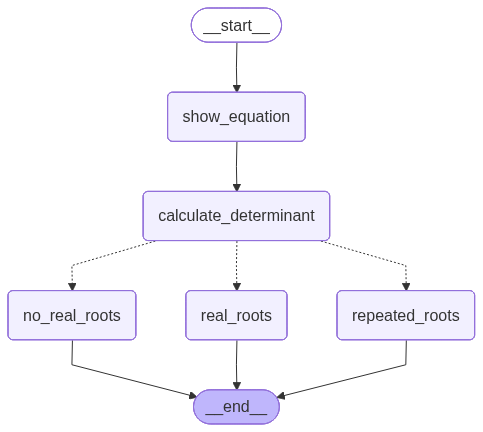

In [8]:
workflow = graph.compile()
workflow

In [9]:
initial_state = {'a' : 12, 'b' : 8, 'c' : 1}
final_state = workflow.invoke(initial_state)

In [10]:
print(final_state['determinant'])

16


In [11]:
print(final_state['equation'])

12x^2 + 8x + 1


In [12]:
print(final_state['result'])

the given equation has two Real Roots, -0.16666666666666666, -0.5 .


In [13]:
initial_state = {'a' : 2, 'b' : 4, 'c' : 2}
final_state = workflow.invoke(initial_state)
print(final_state['equation'])
print(final_state['determinant'])
print(final_state['result'])

2x^2 + 4x + 2
0
the given equation has one repeated root, -1.0 .


In [14]:
initial_state = {'a' : 4, 'b' : -5, 'c' : -4}
final_state = workflow.invoke(initial_state)
print(final_state['equation'])
print(final_state['determinant'])
print(final_state['result'])

4x^2 -5x -4
89
the given equation has two Real Roots, 1.8042476415070754, -0.5542476415070754 .
